- A ideia é fazer modelos por pontos de coleta, P1 a P5.
- 10 dados de saída (elementos químicos) 
- Fazer 10 modelos para cada ponto, totalizando 50 modelos.


1- Utilizar a geração de dados virtuais por interpolação Kriging/GPR. 

2- Gerar 100 modelos por MLP a partir dos dados virtuais e selecionar o melhor pelo critério do R2 e R2vt;

3- A princípio, são 50 modelos. Contudo vocês podem unificar informações visando melhores resultados, por exemplo:
   a. Redes com mais de uma saída;
   b. Juntar pontos. O que leva a mais dados, contudo, pontos diferentes podem se distinguir por variáveis ambientais ou humanas que não foram medidas para serem entradas do modelo;

Essas combinações das informações precisam ser testadas.

4- Os códigos são os de Sarah, já estão prontos ou quase prontos. Os testes iniciais para definir a estratégia é interessante que vocês trabalhem juntas, para discutirem. Também conversem com Willian, em cópia neste e-mail, para avaliarem o que é melhor modelar.

5- Uma vez definida a estratégia a partir dos testes iniciais, vocês podem dividir o trabalho porque são muitos modelos.


Qual o efeito de utilziar uma entrada que não tem correlação com a saida para estima-la? o resultado pode piorar?
Gpr vsg possui problemas para alta dimensionalidade... Então muitas entradas podem piorar o treinamento

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
PREDICTORS = ["pH", "Cond", "Temp", "OD", "Tds", "Resist", "Salin", "ORP", "IP", "Cor"] # 10 entradas

TARGETS = ["Fe", "Al", "As", "Pb", "Zn", "Hg", "Co", "V", "Ba", "Mn"] # 10 saidas

In [3]:
import math

def EvalCorr(n_data, predictors, targets, title="Correlações Entradas × Saídas"):
    num_targets = len(targets)

    # número de linhas e colunas
    rows = 2
    cols = math.ceil(num_targets / 2)

    # ajustar tamanho da figura
    plt.figure(figsize=(5 * cols, 10))  # mais alta para 2 linhas

    for i, target in enumerate(targets):
        plt.subplot(rows, cols, i + 1)

        # manter apenas preditores existentes
        valid_predictors = [p for p in predictors if p in n_data.columns]

        if target not in n_data.columns:
            # saída não existe nesse dataset
            plt.title(f"{target}\n(sem dados)")
            sns.heatmap(np.zeros((1,1)), annot=False, cbar=False)
            continue

        subset = n_data[valid_predictors + [target]]
        corr = subset.corr()[target].drop(target)

        sns.heatmap(
            corr.to_frame(),
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            fmt=".2f"
        )
        plt.title(target)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


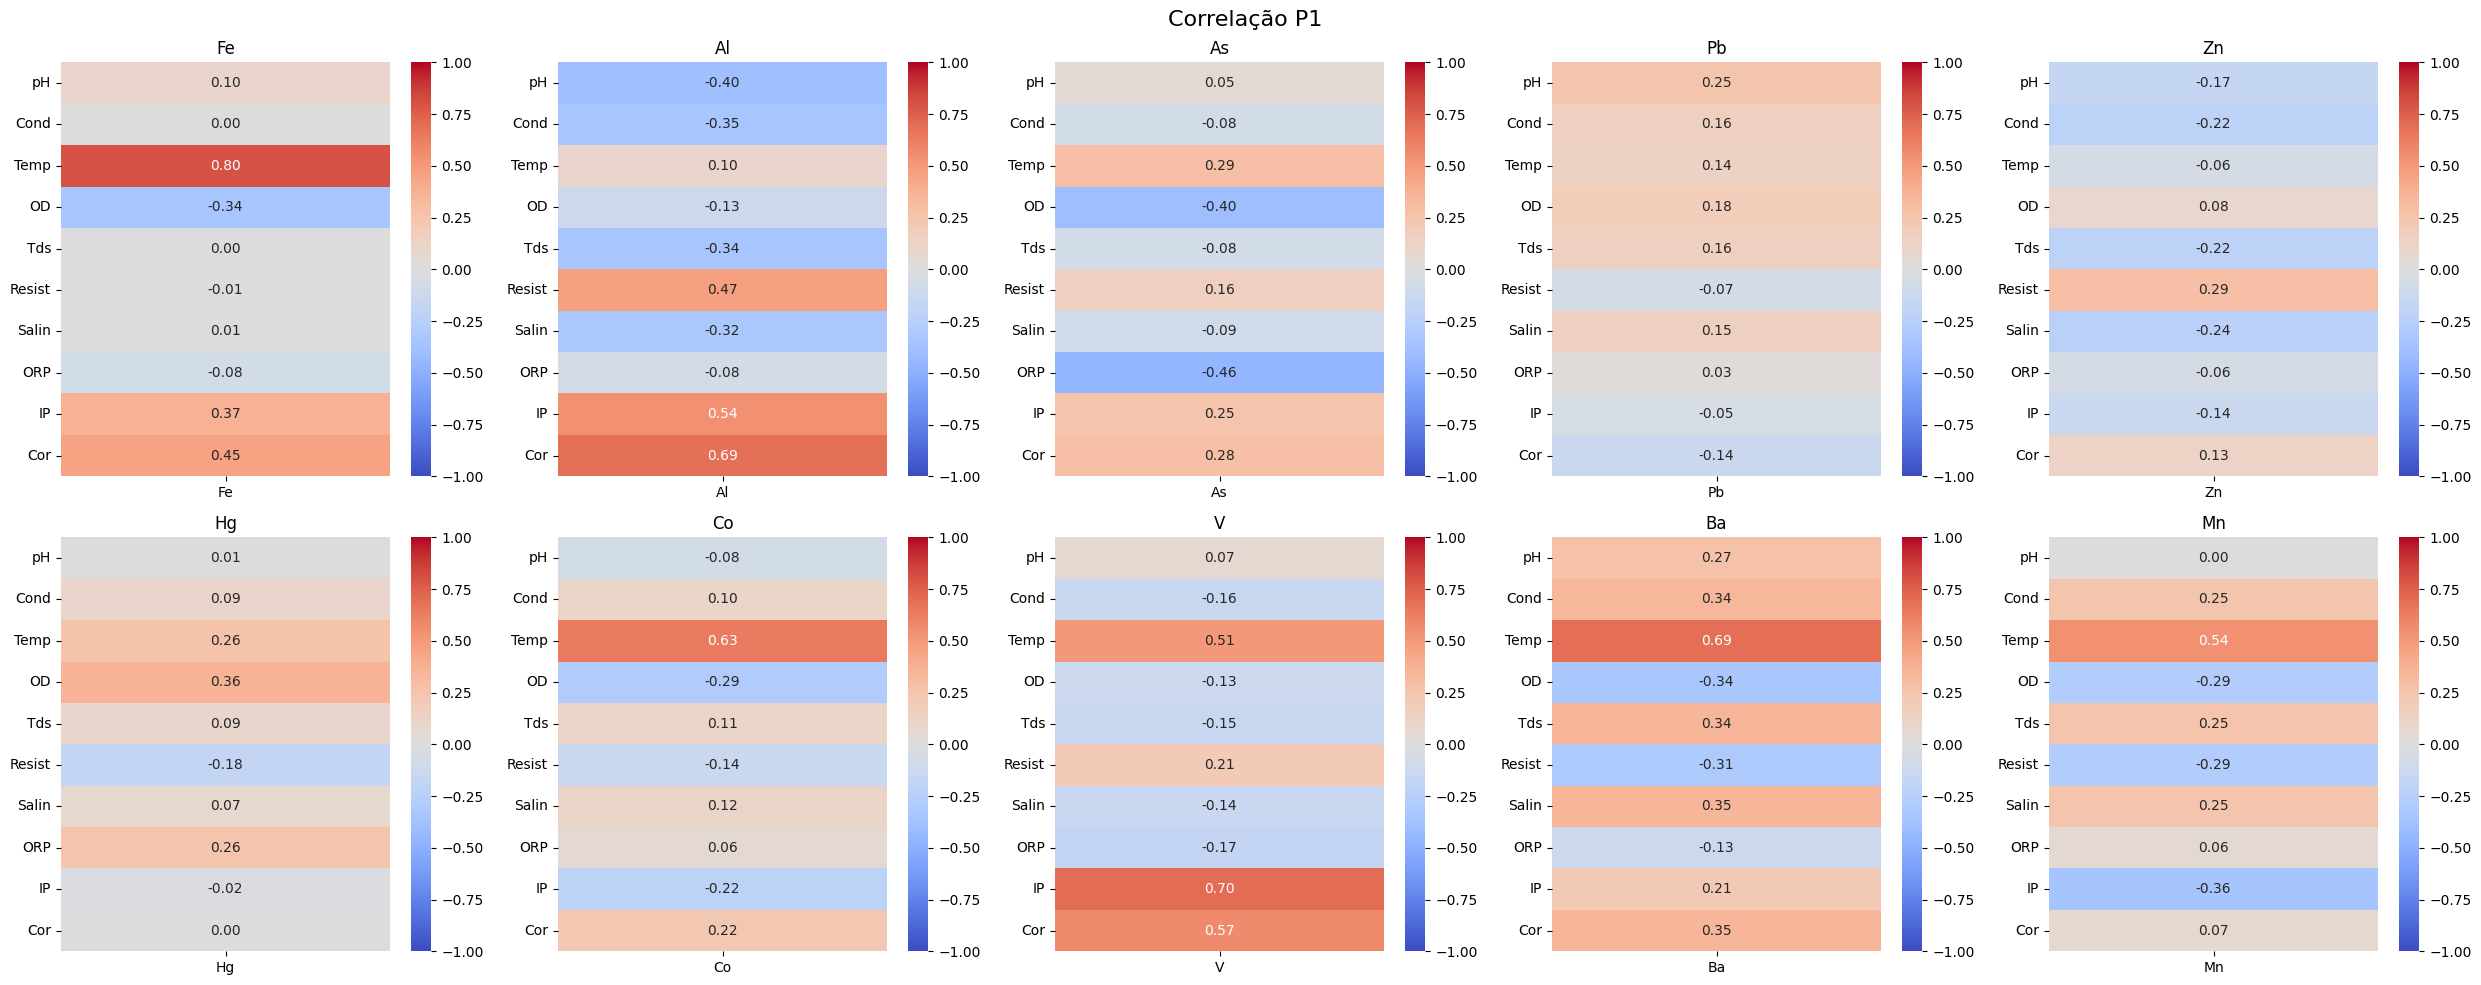

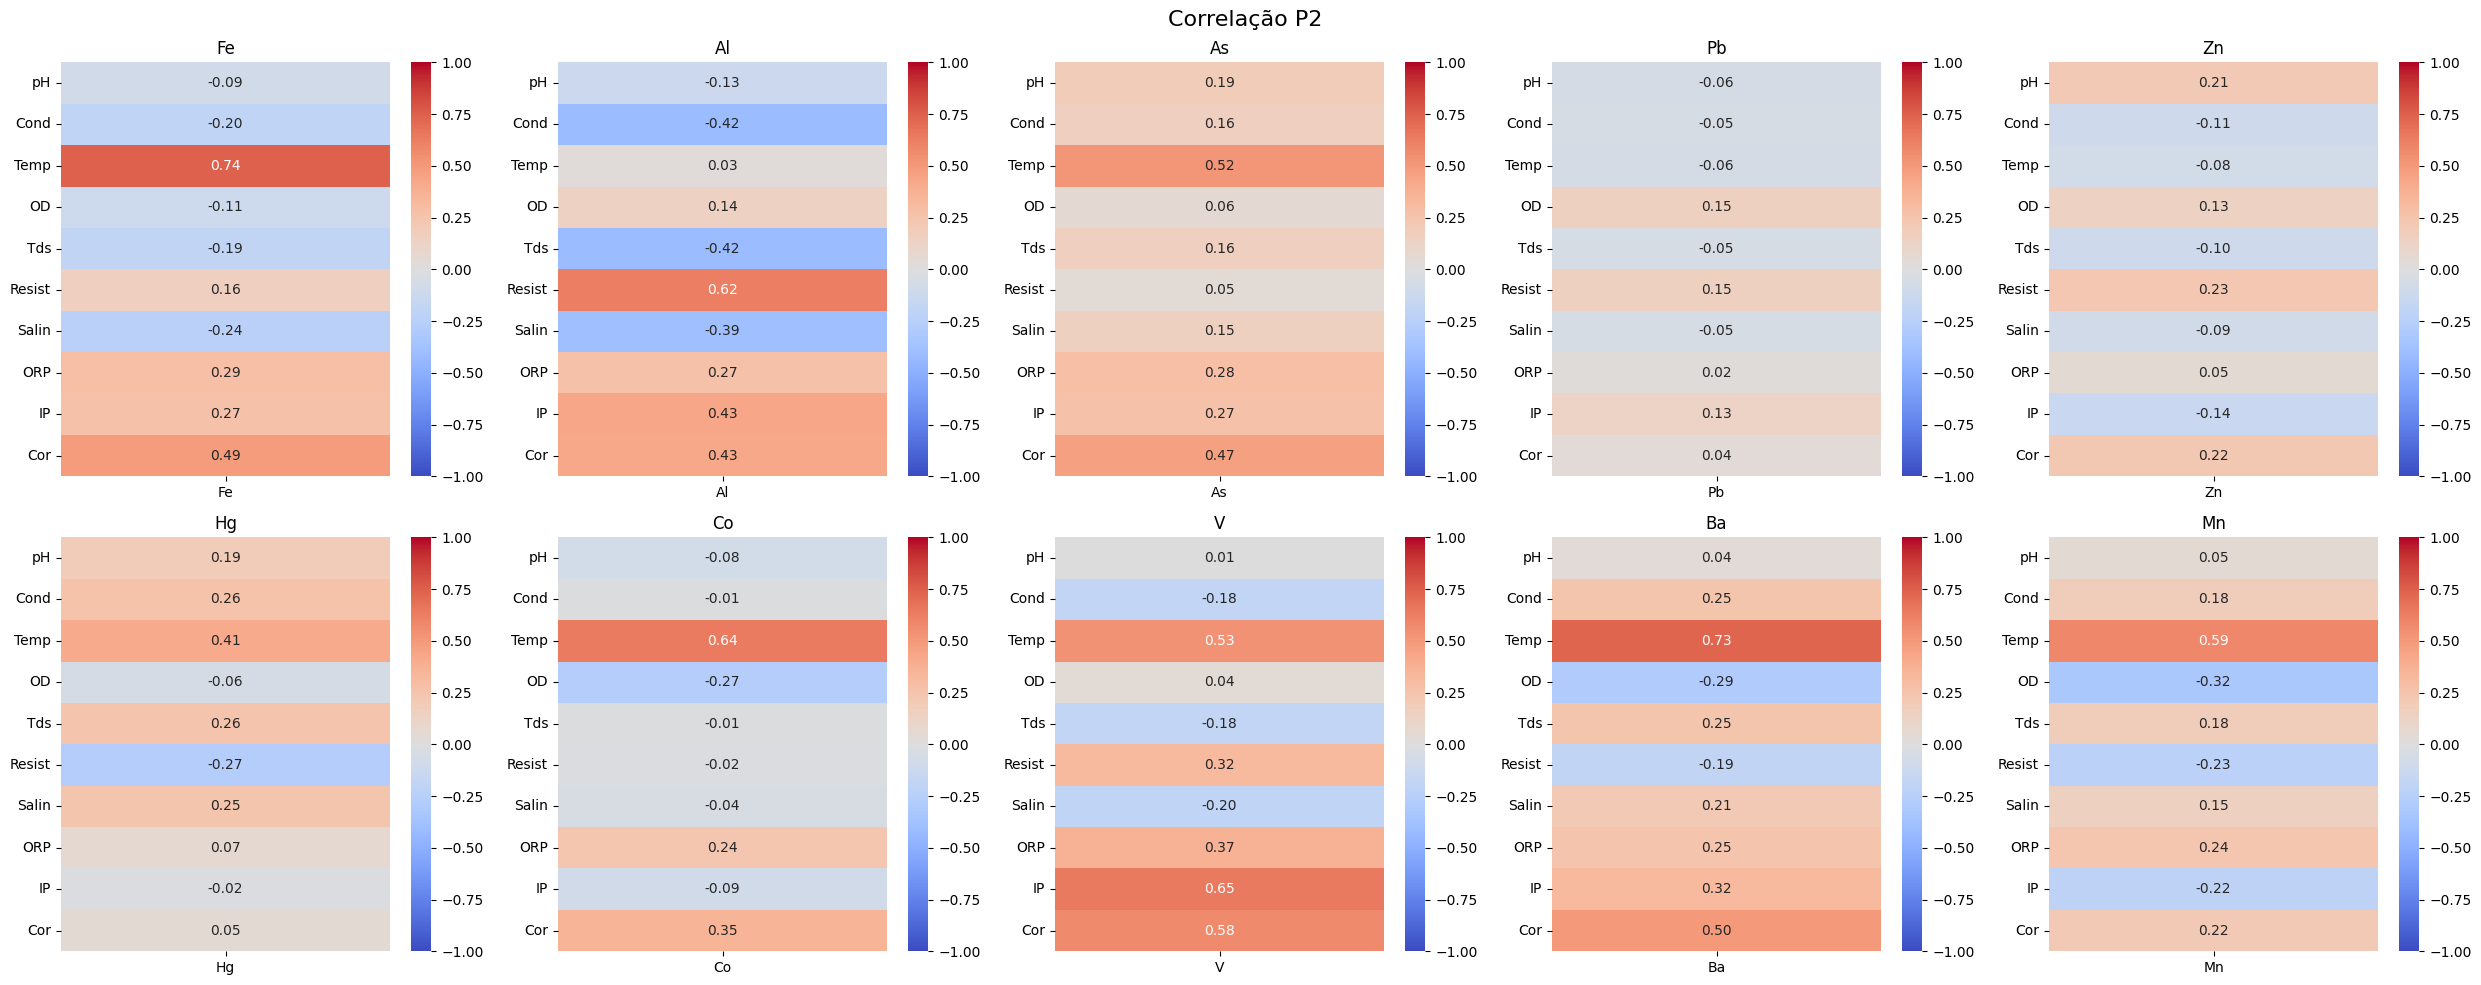

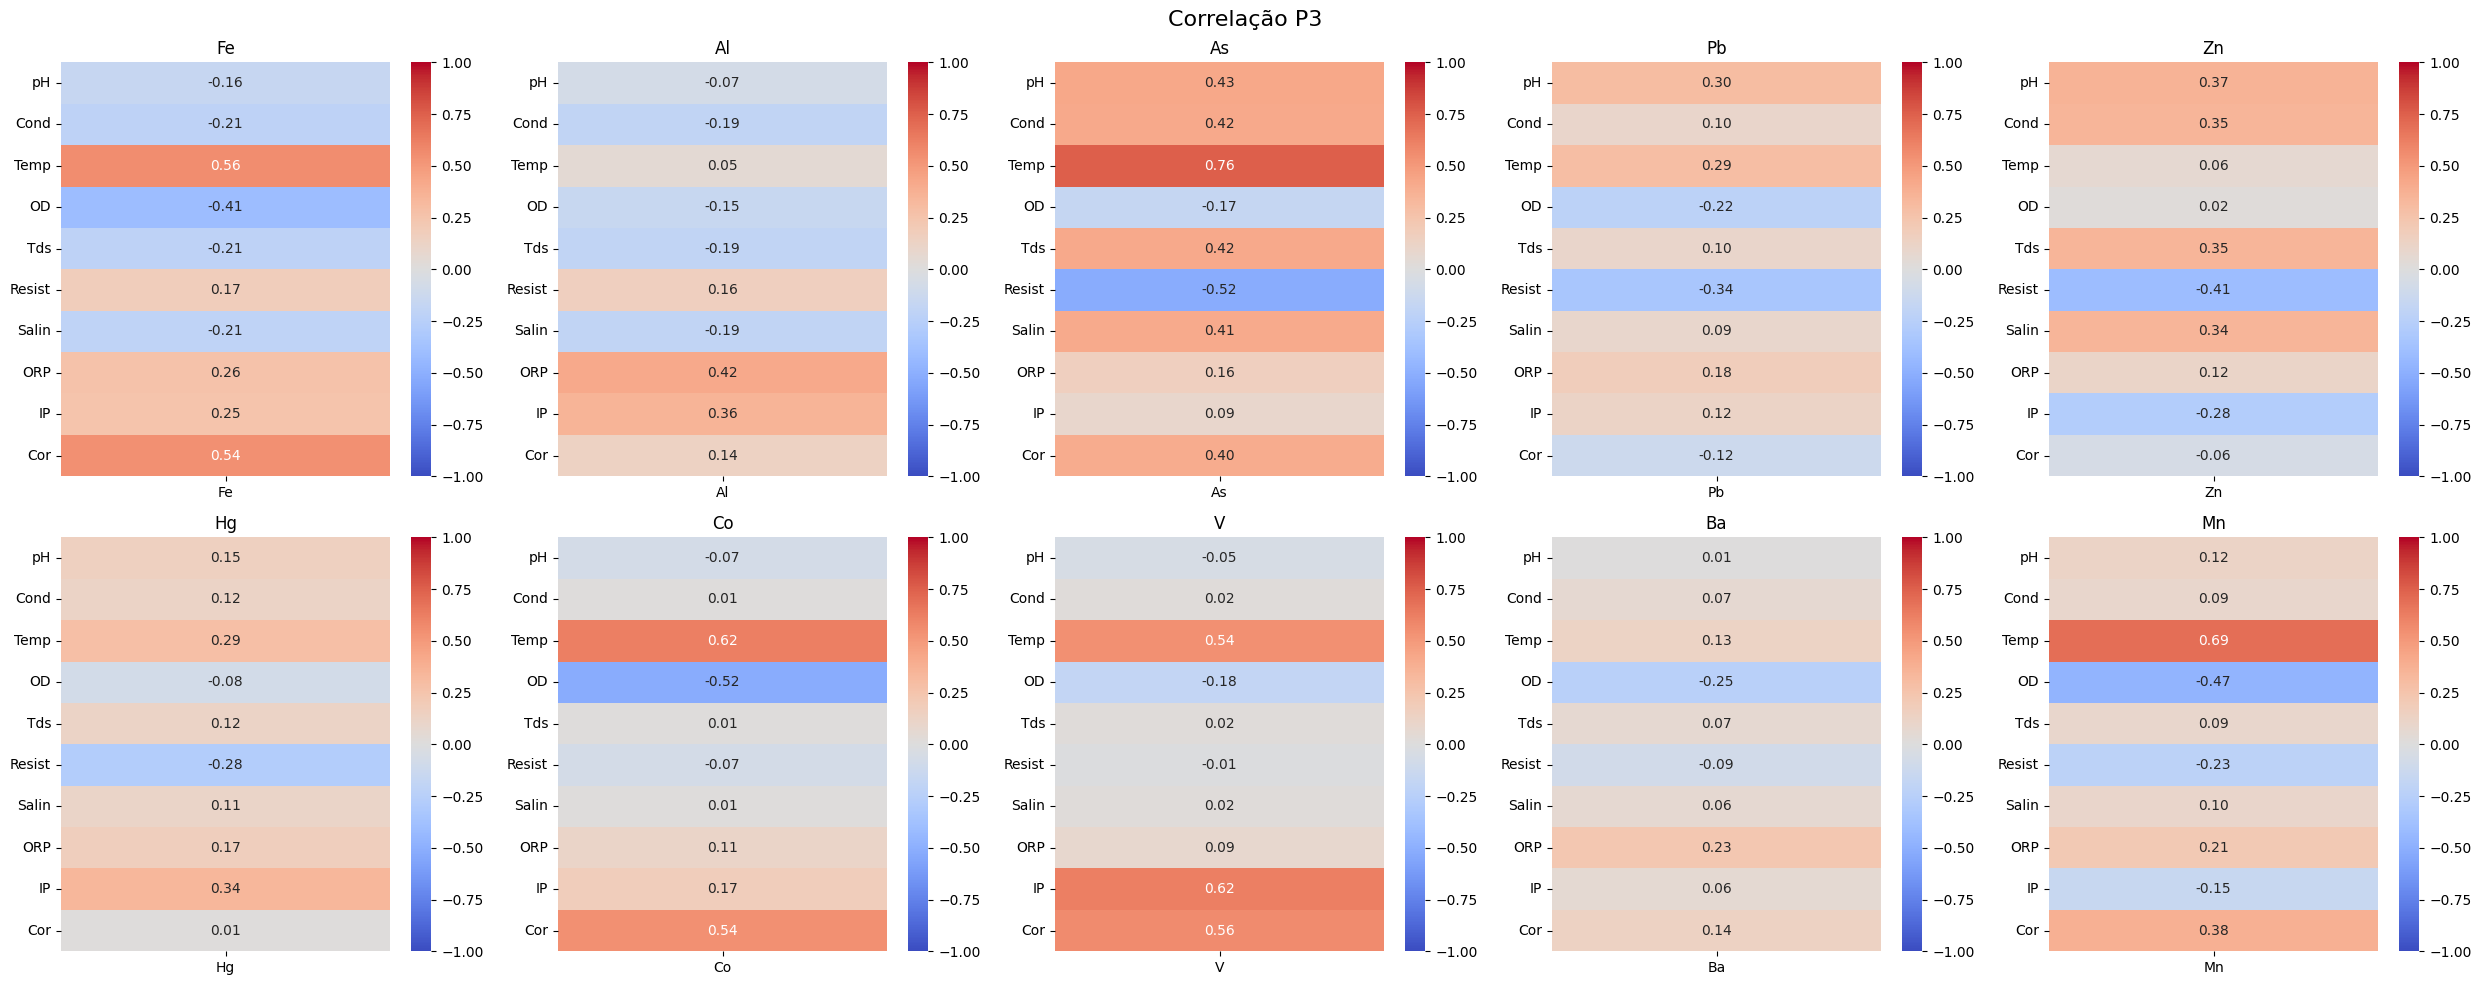

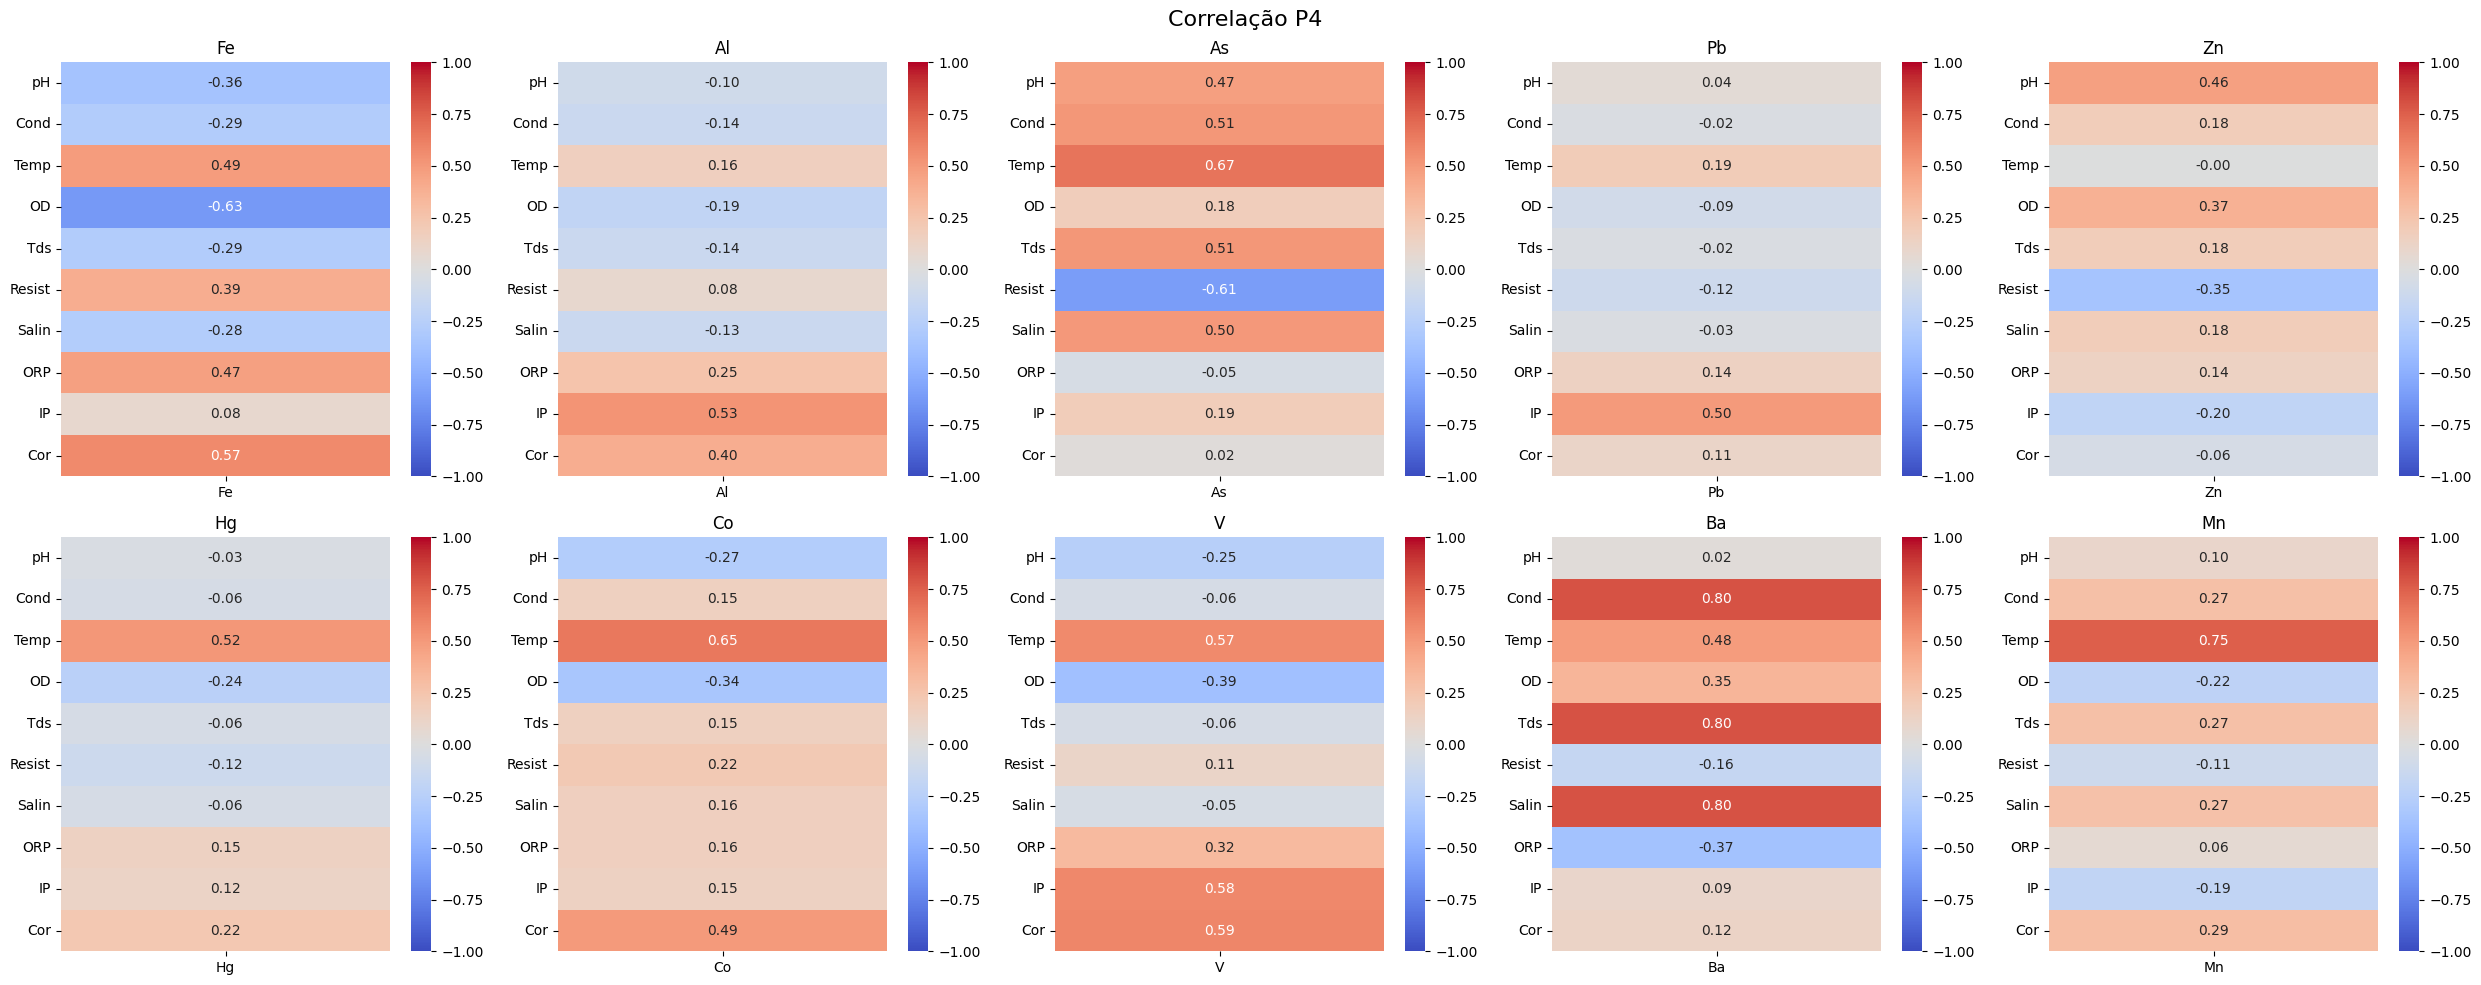

In [4]:
Dataset = pd.read_excel("../Dados/Dados.xlsx")

Datasets = []

for n in range(1, 5):
    n_data = Dataset[ Dataset["Pontos"] == f"P{n}" ]
    n_data = n_data.drop(columns=["Campanhas", "Pontos"])
    EvalCorr(
        n_data,
        predictors=PREDICTORS,
        targets=TARGETS,
        title=f"Correlação P{n}"
    )

    Datasets.append(n_data)
